In [1]:
using Revise
includet("../../cluster_env/runs/si_pdes1/base.jl")

In [2]:
using ProgressMeter
using ColorSchemes
using UnPack
using Statistics

In [3]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# The p colormap

One colour scale for the byproduct diffusion `p`, shared by every plot below so a
colour means the same thing throughout. Linear in `log10(p)` over `p_range`.

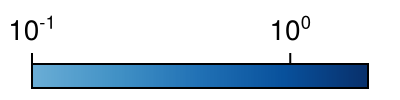

In [34]:
# the first few Blues are too pale to see on white, so the scheme is trimmed. Back
# into a ColorScheme rather than left as the plain Vector{RGB} the indexing returns:
# a vector works as a `colormap=` but `get(v, x, range)` - what p_color needs - is
# only defined on a ColorScheme.
p_colormap = ColorScheme(ColorSchemes.Blues[5:end])
p_range = (1e-1, 2)                       # the p extrema the scale is anchored on
p_logrange = log10.(p_range)               # what a Colorbar's colorrange wants

p_color(p) = get(p_colormap, log10(p), p_logrange)

# for a Colorbar labelled in p rather than log10(p)
p_colorbar_kwargs(ps) = (;
    colormap=p_colormap,
    colorrange=p_logrange,
    ticks=(log10.(ps), [rich("10", superscript(string(Int(log10(p))))) for p in ps]),
)

Makie.Colorbar(Figure(; size=(200, 50))[1, 1];
    vertical=false, p_colorbar_kwargs(10.0 .^ (-2:1))...).parent

In [35]:
p_color.([0.1, 0.2, 0.3, 0.6, 1., 2.])

In [36]:
p_color.([0.1, 1.])

# Coarsening

Total strain biomass space-time diagrams from `main2_totbiom` - 10 SI systems x 5
byproduct diffusions `p`, split across `systems1.jld2`/`systems2.jld2` and run into
`data1`/`data2` - for one system at two chosen `p`.

The first cell loads those runs; "Total biomass vs p" below reuses them.

In [37]:
m2dir = "../../cluster_env/runs/si_pdes1/main2_totbiom/"
m2_halves = [("systems1.jld2", "data1"), ("systems2.jld2", "data2")]

m2_smd = load(joinpath(m2dir, "systems.jld2"), "metadata")
m2_setup_df = load(joinpath(m2dir, "systems.jld2"), "pde_df")

# run_pde_setup numbered its output files by position within the half it was handed,
# so data1 and data2 both start at row0001 and the plain pde_df_row cannot tell them
# apart; orig_rows is the only way back to the position in the unsplit systems.jld2.
# The local index is kept alongside its outdir, since that pair is what
# load_pde_states needs.
m2_df = sort!(vcat(map(m2_halves) do (setup_fname, outdir)
        orig_rows = load(joinpath(m2dir, setup_fname), "orig_rows")
        d = collect_pde_runs(joinpath(m2dir, outdir))
        d.local_row = d.pde_df_row
        d.pde_df_row = orig_rows[d.local_row]
        d.outdir = fill(joinpath(m2dir, outdir), nrow(d))
        d
    end...), :pde_df_row)

m2_ode_df = load(joinpath(m2dir, "test1.jld2"), "df")
m2_states_of(r) = load_pde_states(r.outdir, r.local_row)
m2_hss_of(r) = m2_ode_df.final_states[r.df_row]
m2_hss_biom(r) = sum(m2_hss_of(r)[1:m2_Ns])

m2_Ns, m2_Nr = get_Ns(m2_setup_df.params[1])
m2_ps = m2_smd.ps
m2_sys = sort(unique(m2_df.gdf_row))
m2_T = m2_df.T[1]

@assert all(m2_ode_df.params[r.df_row].c == m2_setup_df.params[r.pde_df_row].c for r in eachrow(m2_df))

@show nrow(m2_df) m2_ps m2_sys m2_T;

nrow(m2_df) = 50
m2_ps = [0.010000000000000002, 0.03162277660168379, 0.1, 0.31622776601683794, 1.0]
m2_sys = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
m2_T = 1.0e8

In [38]:
"""
Cell edges for a heatmap on a log time axis. Makie extrapolates half a cell past
each end, which on these solver time grids lands at or below zero and makes log10
throw; bisecting in log space instead keeps every edge positive.
"""
function log_edges(ts)
    lt = log10.(ts)
    mid = (lt[1:end-1] .+ lt[2:end]) ./ 2
    10 .^ vcat(2 * lt[1] - mid[1], mid, 2 * lt[end] - mid[end])
end

"""
    coarsening_field(r, trange)

Total strain biomass of run `r` over `trange` as `(; edges, xs, ntot)`, ready to
hand to `heatmap!`. The first cell is stretched back to the start of the window -
before it the state is still the untouched initial condition - but the last edge
is pinned to the last saved t rather than the end of the window, so a run that
stopped early stops early on the plot instead of smearing its final state over
the decades it never reached.
"""
function coarsening_field(r, trange)
    (; ts, us) = m2_states_of(r)
    keep = findall(t -> (t > 0.) && (trange[1] <= t <= trange[2]), ts)
    edges = log_edges(ts[keep])
    edges[1] = trange[1]
    edges[end] = ts[keep[end]]
    ntot = permutedims(reduce(hcat, [vec(sum(view(us[k], 1:m2_Ns, :), dims=1)) for k in keep]))
    (; edges, xs=((1:r.sN) .- 0.5) ./ r.sN, ntot)
end

# pick the system and the two ps put side by side
cs_sys = m2_sys[1]
cs_ps = (m2_ps[3], m2_ps[end])

# the solver saves a couple of states at t ~ 1e-17; without a floor here 20 empty
# decades take up most of the log axis. Nothing moves before t ~ 1.
cs_trange = (1e0, m2_T)

cs_rows = [only(eachrow(m2_df[(m2_df.gdf_row.==cs_sys).&(m2_df.p.==p), :])) for p in cs_ps]
cs_fields = [coarsening_field(r, cs_trange) for r in cs_rows]

# a log colour scale: the peaks run to ~10x the well-mixed total while the troughs
# go to zero, which on a linear scale leaves everything but the peaks one flat
# colour. Values are clamped at cs_lo so the empty troughs stay on scale.
cs_lo = 1e-2
cs_hi = maximum(maximum(f.ntot) / m2_hss_biom(r) for (r, f) in zip(cs_rows, cs_fields))

@show cs_sys cs_ps [r.retcode for r in cs_rows] [r.final_T for r in cs_rows] cs_hi;

cs_sys = 1
cs_ps = (0.1, 1.0)[r.retcode for r = cs_rows] = SciMLBase.ReturnCode.T[SciMLBase.ReturnCode.Success, SciMLBase.ReturnCode.Success]
[r.final_T for r = cs_rows] = [1.0e8, 1.0e8]
cs_hi = 7.276435118866496

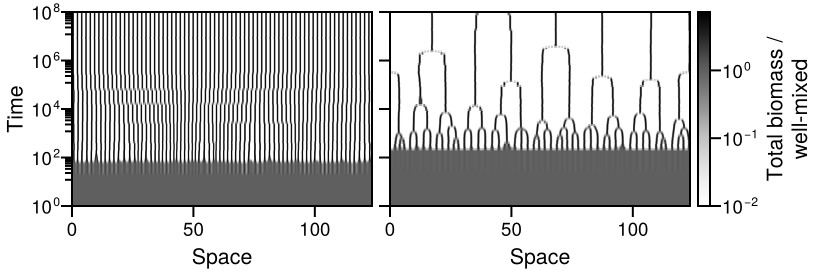

In [39]:
fig = Figure(;
    size=(double_col_width * 0.6, 0.32 * double_col_width / golden_ratio),
    figure_padding=(2., 4., 2., 6.),
)

axs, hms = Axis[], Any[]
for (n, (r, f)) in enumerate(zip(cs_rows, cs_fields))
    ax = Axis(fig[1, n];
        yscale=log10,
        xlabel="Space",
        ylabel=(n == 1 ? "Time" : ""),
        # title=@sprintf("p = %g", r.p),
        # titlesize=8fontsize_pt,
        # titlegap=2.,
        xlabelsize=8fontsize_pt,
        ylabelsize=8fontsize_pt,
        xlabelpadding=2.,
        ylabelpadding=2.,
        xticklabelsize=7fontsize_pt,
        yticklabelsize=7fontsize_pt,
        xticklabelpad=0.,
        yticklabelpad=0.,
        yminorticksvisible=true,
        yminorticks=IntervalsBetween(9),
    )

    push!(hms,
        heatmap!(ax, f.xs .* r.L, f.edges, permutedims(max.(f.ntot ./ m2_hss_biom(r), cs_lo));
            colormap=:Greys, colorscale=log10, colorrange=(cs_lo, cs_hi), rasterize=4
        )
    )

    ylims!(ax, cs_trange...)
    n > 1 && hideydecorations!(ax; ticks=false, grid=false)
    push!(axs, ax)
end

# off the heatmap itself rather than by attribute, so the colorbar cannot disagree
# with the panels about the scale
Colorbar(fig[1, length(cs_rows)+1], hms[end];
    label="Total biomass /\nwell-mixed",
    labelsize=8fontsize_pt,
    labelpadding=2.,
    ticklabelsize=7fontsize_pt,
    ticklabelpad=0.,
    width=6.,
)

colgap!(fig.layout, 4.)

Makie.save("../../figures2/fig3/coarsening.pdf", fig)

fig

# MM coarsening vs time

Peak count over time for the minimal model, `mm_pdes_vs_p/run3_100peaks_DN1e-3`:
5 `p` x 10 reps, each domain sized for `min_peaks` = 100 peaks.

In [64]:
mmdir = "../../cluster_env/runs/mm_pdes_vs_p/run7_final_100peaks_DN1e-3/"

# setup2/main2 is the T=1e7 arm; setup1/main1 is the same 72 rows run out to 1e12
mm_md = load(joinpath(mmdir, "setup2.jld2"), "metadata")
mm_setup_df = load(joinpath(mmdir, "setup2.jld2"), "pde_df")

# Peak counts of every row, precomputed by build_peak_cache - a Dict keyed by
# pde_df_row, which is the row's index into mm_setup_df. Read straight out of the
# jld2 rather than through mm_pdes_vs_p/base.jl: that file defines its own
# collect_pde_runs/load_pde_states and including it would shadow the si_pdes1 ones
# the sections above use. If the file is not there, run build_peak_cache("main2")
# from the run directory once.
mm_cache = load(joinpath(mmdir, "main2", "peak_cache.jld2"), "cache")

@show mm_md.ps mm_md.min_peaks mm_md.T mm_md.sN mm_md.num_reps length(mm_cache);

mm_md.ps = [0.1, 0.1778279410038923, 0.31622776601683794, 0.5623413251903491, 1.0, 2.0]
mm_md.min_peaks = 100
mm_md.T = 1.0e7
mm_md.sN = 5000
mm_md.num_reps = 12
length(mm_cache) = 72

In [67]:
10 .^ range(1, 2, 3)

3-element Vector{Float64}:
  10.0
  31.622776601683793
 100.0

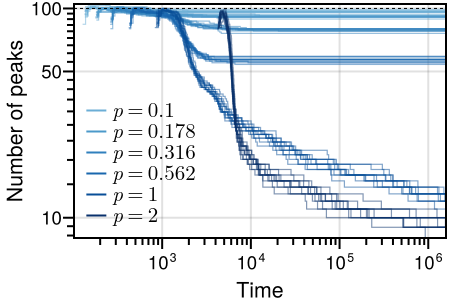

In [101]:
# Each run is cut off before the first save at which it counts at least this
# fraction of the peak count its domain was sized for. Ahead of that the pattern
# has not grown in yet and the count is 0, which a log y axis cannot show.
peak_start_frac = 0.2
mm_np_start = mm_md.min_peaks * (1 - peak_start_frac)

fig = Figure(;
    size=(double_col_width * 0.33, 0.36 * double_col_width / golden_ratio),
    figure_padding=(2., 2., 2., 2.),
)

ax = Axis(fig[1, 1];
    xscale=log10,
    yscale=log10,
    xlabel="Time",
    ylabel="Number of peaks",
    xlabelsize=8fontsize_pt,
    ylabelsize=8fontsize_pt,
    xlabelpadding=2.,
    ylabelpadding=2.,
    xticklabelsize=7fontsize_pt,
    # yticks=[10, 30, 50, 70, 100],
    yticks=[10, 50, 100],
    yticklabelsize=7fontsize_pt,
    xticklabelpad=0.,
    yticklabelpad=0.,
    xminorticksvisible=true,
    xminorticks=IntervalsBetween(9),
    yminorticksvisible=true,
    yminorticks=IntervalsBetween(9),
)

mm_t_onset = Inf
for i in sort(collect(keys(mm_cache)))
    (; ts, np) = mm_cache[i]
    k0 = findfirst(>=(mm_np_start), np)
    if isnothing(k0)
        @warn @sprintf("row %d never reaches %.5g peaks, skipped", i, mm_np_start)
        continue
    end
    global mm_t_onset = min(mm_t_onset, ts[k0])
    stairs!(ax, ts[k0:end], np[k0:end];
        step=:post, color=(p_color(mm_setup_df.p[i]), 0.5), linewidth=0.6)
end

hlines!(ax, mm_md.min_peaks; color=:black, linestyle=:dash, linewidth=0.5)

axislegend(ax,
    [LineElement(; color=p_color(p), linewidth=1.) for p in mm_md.ps],
    [latexstring(@sprintf("p = %.3g", p)) for p in mm_md.ps];
    position=:lb,
    labelsize=7fontsize_ltex_pt,
    framevisible=false,
    backgroundcolor=:transparent,
    patchsize=(10., 4.),
    patchlabelgap=3.,
    rowgap=0.,
    padding=(0., 0., 0., 0.),
)

xlims!(ax, 0.8mm_t_onset, 10^6.2)
ylims!(ax, 8, 105)

Makie.save("../../figures2/fig3/mm_numpeaks_vs_t.pdf", fig)

fig

In [42]:
# The same p legend on its own, for placing by hand next to a panel that has had
# its own legend turned off. Same elements and text sizes as the plot above, laid
# out horizontally; resize_to_layout! crops the figure down to just the legend.
fig = Figure(; figure_padding=(2., 2., 2., 2.))

Legend(fig[1, 1],
    [LineElement(; color=p_color(p), linewidth=1.) for p in mm_md.ps],
    [latexstring(@sprintf("p = %.3g", p)) for p in mm_md.ps];
    orientation=:horizontal,
    tellwidth=true,   # false for a horizontal Legend by default, which leaves
                      # resize_to_layout! nothing to crop the width down to
    labelsize=7fontsize_ltex_pt,
    framevisible=false,
    backgroundcolor=:transparent,
    patchsize=(10., 4.),
    patchlabelgap=3.,
    colgap=8.,
    padding=(0., 0., 0., 0.),
)

resize_to_layout!(fig)

Makie.save("../../figures2/fig3/mm_p_legend.pdf", fig)

fig

## Averaged over reps

The same counts, meaned across the reps of each `p` on a common log `t` grid, with
a +-std band. Uses `mm_np_start` from the cell above as the start cutoff.

In [43]:
# Each run's count is resampled onto a log t grid by previous-value lookup - the
# count is a step function of t, so that is exact rather than an interpolation
# error - starting from the same peak_start_frac cutoff as above.
#
# A run that stops before mm_min_final_t is dropped rather than extrapolated.
#
# One grid *per p*, not one shared by all of them: onset is strongly p dependent
# (t ~ 70 at p = 0.01 against t ~ 880 at p = 1), so a single grid starting at the
# latest onset of the whole set would throw away more than a decade of the low p
# runs. Within one p the reps onset within a few percent of each other, so a grid
# from that p's latest onset to its earliest end costs almost nothing and keeps
# every gridpoint a mean over the same reps, with no extrapolation at either end.
mm_min_final_t = 1e6
mm_nt = 200

mm_onset_i(i) = findfirst(>=(mm_np_start), mm_cache[i].np)
mm_onset_t(i) = mm_cache[i].ts[mm_onset_i(i)]

mm_kept = filter(sort(collect(keys(mm_cache)))) do i
    (mm_cache[i].ts[end] >= mm_min_final_t) && !isnothing(mm_onset_i(i))
end
@printf("%d/%d runs kept\n", length(mm_kept), length(mm_cache))

mm_np_on_grid(i, tgrid) = [float(mm_cache[i].np[searchsortedlast(mm_cache[i].ts, t)])
                           for t in tgrid]

mm_pstats = map(enumerate(mm_md.ps)) do (j, p)
    rows = filter(i -> mm_setup_df.p_i[i] == j, mm_kept)
    ts = 10 .^ range(log10(maximum(mm_onset_t, rows)),
        log10(minimum(i -> mm_cache[i].ts[end], rows)), mm_nt)
    counts = reduce(hcat, [mm_np_on_grid(i, ts) for i in rows])  # mm_nt x nreps
    (; p, n=length(rows), ts, mean=vec(mean(counts; dims=2)), std=vec(std(counts; dims=2)))
end

DataFrame(; p=[s.p for s in mm_pstats], n=[s.n for s in mm_pstats],
    t_start=[s.ts[1] for s in mm_pstats],
    first_mean=[s.mean[1] for s in mm_pstats],
    final_mean=[s.mean[end] for s in mm_pstats],
    final_std=[s.std[end] for s in mm_pstats])

72/72 runs kept

Row,p,n,t_start,first_mean,final_mean,final_std
,Float64,Int64,Float64,Float64,Float64,Float64
1,0.1,12,137.038,94.5833,96.5833,1.24011
2,0.177828,12,182.005,93.0,91.3333,0.984732
3,0.316228,12,264.966,88.8333,78.8333,1.19342
4,0.562341,12,453.018,93.1667,56.6667,1.557
5,1.0,12,943.011,93.9167,10.6667,0.492366
6,2.0,12,4567.48,91.0,7.66667,0.651339


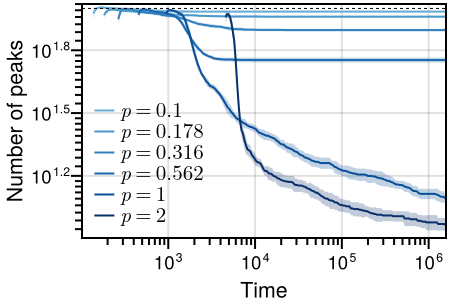

In [102]:
mm_ylo = 0.8

fig = Figure(;
    size=(double_col_width * 0.33, 0.36 * double_col_width / golden_ratio),
    figure_padding=(2., 2., 2., 2.),
)

ax = Axis(fig[1, 1];
    xscale=log10,
    yscale=log10,
    xlabel="Time",
    ylabel="Number of peaks",
    xlabelsize=8fontsize_pt,
    ylabelsize=8fontsize_pt,
    xlabelpadding=2.,
    ylabelpadding=2.,
    xticklabelsize=7fontsize_pt,
    yticklabelsize=7fontsize_pt,
    xticklabelpad=0.,
    yticklabelpad=0.,
    xminorticksvisible=true,
    xminorticks=IntervalsBetween(9),
    yminorticksvisible=true,
    yminorticks=IntervalsBetween(9),
)

# bands first so the means sit on top of them. Each p is on its own t grid,
# starting at its own onset - see the cell above.
for s in mm_pstats
    band!(ax, s.ts, max.(s.mean .- s.std, mm_ylo), s.mean .+ s.std;
        color=(p_color(s.p), 0.25))
end
for s in mm_pstats
    lines!(ax, s.ts, s.mean; color=p_color(s.p), linewidth=1.)
end

hlines!(ax, mm_md.min_peaks; color=:black, linestyle=:dash, linewidth=0.5)

axislegend(ax,
    [LineElement(; color=p_color(p), linewidth=1.) for p in mm_md.ps],
    [latexstring(@sprintf("p = %.3g", p)) for p in mm_md.ps];
    position=:lb,
    labelsize=7fontsize_ltex_pt,
    framevisible=false,
    backgroundcolor=:transparent,
    patchsize=(10., 4.),
    patchlabelgap=3.,
    rowgap=0.,
    padding=(0., 0., 0., 0.),
)

# xlims!(ax, 0.8mm_t_onset, 10^6.2)
# ylims!(ax, 10, 105)
xlims!(ax, 0.8mm_t_onset, 10^6.2)
ylims!(ax, 8, 105)

Makie.save("../../figures2/fig3/mm_numpeaks_vs_t_mean.pdf", fig)

fig

# Total biomass vs time

`main4_totbiom`, one line per run, coloured by `p`. `run_stats.jld2` carries the
biomass series without the states, so nothing is read off `data/` here.

In [84]:
m8dir = "../../cluster_env/runs/si_pdes1/main8_totbiom/"

m8_setup_df = load(joinpath(m8dir, "systems.jld2"), "pde_df")
m8_smd = load(joinpath(m8dir, "systems.jld2"), "metadata")
m8_df = collect_pde_runs(joinpath(m8dir, "data"))

# extinct strains were dropped at setup, so Ns varies by system and the hss is
# carried per row in the setup file
m8_df.Ns = [get_Ns(m8_setup_df.params[i])[1] for i in m8_df.pde_df_row]
m8_df.B_hss = [sum(m8_setup_df.ode_hss[i][1:ns]) for (i, ns) in zip(m8_df.pde_df_row, m8_df.Ns)]
m8_T = m8_df.T[1]

# one pass over the saved states (~3GB), keeping only the spatial mean of the total
# strain biomass at each saved t - mean not integral, since L differs between runs
m8_ts = Vector{Vector{Float64}}(undef, nrow(m8_df))
m8_Bmean = Vector{Vector{Float64}}(undef, nrow(m8_df))
@showprogress for (k, r) in enumerate(eachrow(m8_df))
    (; ts, us) = load_pde_states(joinpath(m8dir, "data"), r.pde_df_row)
    keep = findall(>(0.0), ts)   # t = 0 has no place on a log axis
    m8_ts[k] = ts[keep]
    m8_Bmean[k] = [sum(mean(view(us[j], 1:r.Ns, :); dims=2)) for j in keep]
    GC.gc()
end
m8_df.ts, m8_df.Bmean = m8_ts, m8_Bmean

@printf("%d/%d rows, retcodes %s\n", nrow(m8_df), nrow(m8_setup_df),
    string(sort(unique(string.(m8_df.retcode)))))
@show m8_smd.ps m8_T length(unique(m8_df.gdf_row));

Progress: 100%|█████████████████████████████████████████| Time: 0:00:40

40/40 rows, retcodes ["MaxTime", "Success"]
m8_smd.ps = [0.1, 1.0]
m8_T = 1.0e8
length(unique(m8_df.gdf_row)) = 20

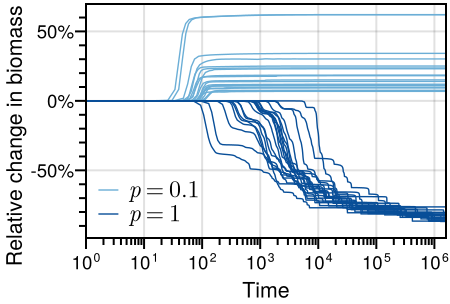

In [103]:
fig = Figure(;
    size=(double_col_width * 0.33, 0.36 * double_col_width / golden_ratio),
    figure_padding=(2., 2., 2., 2.),
)

ax = Axis(fig[1, 1];
    xscale=log10,
    xlabel="Time",
    ylabel="Relative change in biomass     ",
    xlabelsize=8fontsize_pt,
    ylabelsize=8fontsize_pt,
    xlabelpadding=2.,
    ylabelpadding=2.,
    xticklabelsize=7fontsize_pt,
    yticklabelsize=7fontsize_pt,
    xticklabelpad=0.,
    yticklabelpad=0.,
    yticks=([-0.5, 0., 0.5], ["-50%", "0%", "50%"]),
    xminorticksvisible=true,
    xminorticks=IntervalsBetween(9),
    yminorticksvisible=true,
    yminorticks=IntervalsBetween(5),
)

# one line per run; the last of each p is kept only to hang the legend entry on
plines = map(m8_smd.ps) do p
    pcol = p_color(p)
    local pl = nothing
    for r in eachrow(m8_df[m8_df.p.==p, :])
        pl = lines!(ax, r.ts, (r.Bmean .- r.B_hss) ./ r.B_hss;
            color=pcol, linewidth=0.7)
    end
    pl
end

axislegend(ax, plines, [latexstring(@sprintf("p = %g", p)) for p in m8_smd.ps];
    position=:lb,
    framevisible=false,
    labelsize=8fontsize_ltex_pt,
    patchsize=(10., 4.),
    padding=(0., 0., 0., 0.),
    rowgap=0.,
)

xlims!(ax, 1., 10^6.2)

Makie.save("../../figures2/fig3/totbiom_vs_t.pdf", fig)

fig

# Total biomass vs p

Same `main2_totbiom` runs as the Coarsening section, which is where `m2_df` and
friends are loaded - run that section's first cell before these.

In [20]:
# Total biomass (spatial mean of the strain sum - sN is the same for every run but L
# is not) at a fixed t, linearly interpolated between the two saved states
# bracketing it. `missing` where t falls outside the saved range - never extrapolated.
t_at = 1e5

function m2_biomass_at(r, t)
    (; ts, us) = m2_states_of(r)
    (t < ts[1] || t > ts[end]) && return missing
    biom(u) = sum(mean(view(u, 1:m2_Ns, :), dims=2))
    j = searchsortedfirst(ts, t)
    j == 1 && return biom(us[1])   # t == ts[1] exactly
    w = (t - ts[j-1]) / (ts[j] - ts[j-1])
    (1 - w) * biom(us[j-1]) + w * biom(us[j])
end

m2_bdf = sort(DataFrame(; m2_df.gdf_row, m2_df.p,
        biomass_t_at=[m2_biomass_at(r, t_at) for r in eachrow(m2_df)],
        hss=[m2_hss_biom(r) for r in eachrow(m2_df)]),
    [:gdf_row, :p])
m2_bdf.rel = m2_bdf.biomass_t_at ./ m2_bdf.hss

# mean and std across systems at each p; a run that has not reached t_at is left out
# of its p rather than counted, so n is not the same for every point
m2_pstats = combine(groupby(m2_bdf, :p),
    :rel => (v -> mean(skipmissing(v))) => :mean,
    :rel => (v -> std(skipmissing(v))) => :std,
    :rel => (v -> count(!ismissing, v)) => :n)

Row,p,mean,std,n
,Float64,Float64,Float64,Int64
1,0.01,1.38966,0.246875,10
2,0.0316228,1.30204,0.176442,10
3,0.1,1.17577,0.121235,10
4,0.316228,0.981738,0.0800535,9
5,1.0,0.292182,0.222783,9


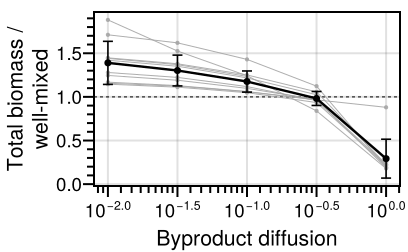

In [21]:
fig = Figure(;
    size=(double_col_width * 0.30, 0.30 * double_col_width / golden_ratio),
    figure_padding=(2., 4., 2., 6.),
)

ax = Axis(fig[1, 1];
    xscale=log10,
    xlabel="Byproduct diffusion",
    ylabel="Total biomass /\nwell-mixed",
    xlabelsize=8fontsize_pt,
    ylabelsize=8fontsize_pt,
    xlabelpadding=2.,
    ylabelpadding=2.,
    xticklabelsize=7fontsize_pt,
    yticklabelsize=7fontsize_pt,
    xticklabelpad=0.,
    yticklabelpad=0.,
    xminorticksvisible=true,
    xminorticks=IntervalsBetween(9),
    yminorticksvisible=true,
    yminorticks=IntervalsBetween(5),
)

hlines!(ax, 1.0; color=:black, linestyle=:dash, linewidth=0.5)

for sy in m2_sys
    g = m2_bdf[m2_bdf.gdf_row.==sy, :]
    # NaN rather than dropped, so a p that has not reached t_at leaves a gap in the
    # line instead of a segment straight across it
    scatterlines!(ax, g.p, coalesce.(g.rel, NaN);
        color=(:grey65, 0.9), markersize=3, linewidth=0.5)
end
errorbars!(ax, m2_pstats.p, m2_pstats.mean, m2_pstats.std;
    color=:black, whiskerwidth=5, linewidth=0.8)
scatterlines!(ax, m2_pstats.p, m2_pstats.mean;
    color=:black, markersize=5, linewidth=1.2)

Makie.save("../../figures2/fig3/totbiom_vs_p2.pdf", fig)

fig

# Relative abundances 2

`main9_commcomp` - 100 systems x 3 `p`. The hss is stored in the setup file and the
extinct strains were already dropped from the params, so the strain block is all of
`1:Ns` and `Ns` varies by system.

In [47]:
m9dir = "../../cluster_env/runs/si_pdes1/main9_commcomp/"

m9_setup_df = load(joinpath(m9dir, "systems2.jld2"), "pde_df")
m9_smd = load(joinpath(m9dir, "systems2.jld2"), "metadata")
m9_all_runs = collect_pde_runs(joinpath(m9dir, "data"))   # only the rows that have a file

# drop the runs that stopped before their T - their final state is not a converged
# one, so it has no business in a composition comparison
m9_finished = m9_all_runs.final_T .>= m9_all_runs.T
m9_runs = m9_all_runs[m9_finished, :]
@printf("excluded %d/%d runs that did not reach T = %.3g\n",
    count(.!m9_finished), nrow(m9_all_runs), m9_all_runs.T[1])

m9_df = DataFrame(map(eachrow(m9_runs)) do r
    s = m9_setup_df[r.pde_df_row, :]
    Ns, Nr = get_Ns(s.ode_params)
    (;
        sys=r.gdf_row,
        r.p,
        hss=s.ode_hss,
        pde_fs=r.final_state,
        so_hss=s.ode_hss[1:Ns],
        so_fs=vec(mean(view(r.final_state, 1:Ns, :); dims=2)),
    )
end)

@printf("%d/%d rows, retcodes %s\n", nrow(m9_df), nrow(m9_setup_df),
    string(sort(unique(string.(m9_runs.retcode)))))
@printf("strains per system: %d - %d\n", extrema(length.(m9_df.so_hss))...)

names(m9_df)

excluded 4/300 runs that did not reach T = 1e+08
296/300 rows, retcodes ["Success"]strains per system: 2 - 8

6-element Vector{String}:
 "sys"
 "p"
 "hss"
 "pde_fs"
 "so_hss"
 "so_fs"

## Histogram of relative abundance rations

In [48]:
gbp = groupby(m9_df, :p);

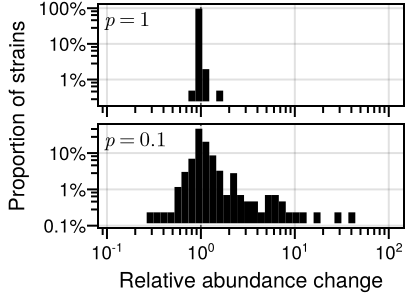

In [49]:
m9_hist_ps = (1.0, 0.1)
m9_hist_ethr = 1e-6
m9_hist_nbins = 40

# Relative abundance in the PDE final state over the same in the well-mixed steady
# state, per surviving strain, pooled over systems. Strains that went extinct fall
# below ethr and are dropped - the ratio is 0 there and has no place on a log axis.
function m9_relchange(p; ethr=m9_hist_ethr)
    xs = Float64[]
    for r in eachrow(m9_df[m9_df.p.==p, :])
        append!(xs, (r.so_fs ./ sum(r.so_fs)) ./ (r.so_hss ./ sum(r.so_hss)))
    end
    (; live=filter(>(ethr), xs), nextinct=count(<=(ethr), xs))
end

m9_hists = [m9_relchange(p) for p in m9_hist_ps]

# one set of log spaced edges for both panels, so the two are directly comparable
m9_edges = 10 .^ range(extrema(log10.(vcat((h.live for h in m9_hists)...)))..., m9_hist_nbins + 1)

fig = Figure(;
    size=(double_col_width * 0.30, 0.35 * double_col_width / golden_ratio),
    figure_padding=(2., 2., 2., 2.),
)

axs = Axis[]
for (n, (p, h)) in enumerate(zip(m9_hist_ps, m9_hists))
    ax = Axis(fig[n, 1];
        xscale=log10,
        yscale=log10,
        xlabel=(n == length(m9_hist_ps) ? "Relative abundance change" : ""),
        xticks=log10ticks(-1:2),
        yticks=(10.0 .^ (-3:0), ["0.1%", "1%", "10%", "100%"]),
        xminorticks=IntervalsBetween(9),
        xminorticksvisible=true,
        xlabelsize=8fontsize_pt,
        xlabelpadding=2.,
        xticklabelsize=7fontsize_pt,
        yticklabelsize=7fontsize_pt,
        xticklabelpad=0.,
        yticklabelpad=0.,
        yminorticksvisible=true,
        yminorticks=IntervalsBetween(5),
    )

    hist!(ax, h.live;
        bins=m9_edges,
        normalization=:probability,
        color=:black,
        # color=p_color(p)
    )
    vlines!(ax, 1.0; color=:black, linestyle=:dash, linewidth=0.5)  # no change

    text!(ax, 0.02, 0.95;
        text=latexstring(@sprintf("p = %.3g", p)),
        space=:relative, align=(:left, :top), fontsize=7fontsize_ltex_pt)

    push!(axs, ax)
end

linkxaxes!(axs...)
xlims!(axs[1], extrema(m9_edges)...)
# x is shared, so only label it once
hidexdecorations!(axs[1]; ticks=false, minorticks=false, grid=false)

Label(fig[1:length(axs), 0], "Proportion of strains";
    fontsize=8fontsize_pt, rotation=pi / 2, padding=(0., 2., 0., 0.))

rowgap!(fig.layout, 4.)
colgap!(fig.layout, 4.)

Makie.save("../../figures2/fig3/relabund_hist.pdf", fig)

fig

## Jensen-Shannon divergence

Between the strain relative abundances of the well-mixed steady state and of the
PDE final state, per run. Log base 2, so 0 is identical and 1 is disjoint support.

In [50]:
"""
    jsdiv(u, v)

Jensen-Shannon divergence between two abundance vectors, each normalised to sum 1
first. Log base 2, so it runs from 0 (identical) to 1 (disjoint support). Terms
where a distribution is 0 contribute nothing, which is the 0 log 0 = 0 limit.
"""
function jsdiv(u, v)
    a = u ./ sum(u)
    b = v ./ sum(v)
    m = (a .+ b) ./ 2
    kl(x) = sum(xi == 0 ? 0.0 : xi * log2(xi / mi) for (xi, mi) in zip(x, m))
    (kl(a) + kl(b)) / 2
end

m9_df.jsd = [jsdiv(r.so_hss, r.so_fs) for r in eachrow(m9_df)]

combine(groupby(m9_df, :p),
    :jsd => minimum => :min,
    :jsd => median => :median,
    :jsd => maximum => :max)

Row,p,min,median,max
,Float64,Float64,Float64,Float64
1,0.01,7.02244e-5,0.00473057,0.131217
2,0.1,2.7576e-5,0.00258621,0.0925422
3,1.0,3.53201e-9,5.13524e-7,0.000232238


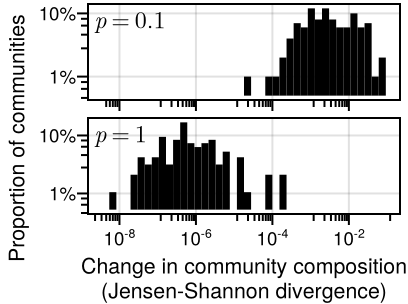

In [106]:
m9_jsd_hist_ps = (0.1, 1.0)
m9_jsd_hist_nbins = 40

# one jsd per run, pooled over systems at each p
m9_jsds = [m9_df[m9_df.p.==p, :jsd] for p in m9_jsd_hist_ps]

# one set of log spaced edges for both panels, so the two are directly comparable
m9_jsd_edges = 10 .^ range(extrema(log10.(vcat(m9_jsds...)))..., m9_jsd_hist_nbins + 1)

fig = Figure(;
    size=(double_col_width * 0.30, 0.36 * double_col_width / golden_ratio),
    figure_padding=(2., 4., 2., 2.),
)

# xlabel = "Jensen-Shannon divergence"
# xlabel = "Change in community composition\nwell-mixed vs. patterned\n(Jensen-Shannon divergence)"
xlabel = "Change in community composition\n(Jensen-Shannon divergence)"
axs = Axis[]
for (n, (p, xs)) in enumerate(zip(m9_jsd_hist_ps, m9_jsds))
    ax = Axis(fig[n, 1];
        xscale=log10,
        yscale=log10,
        xlabel=(n == length(m9_jsd_hist_ps) ? xlabel : ""),
        xticks=log10ticks(-8:2:0),
        yticks=(10.0 .^ (-3:0), ["0.1%", "1%", "10%", "100%"]),
        xminorticks=IntervalsBetween(9),
        xminorticksvisible=true,
        xlabelsize=8fontsize_pt,
        xlabelpadding=2.,
        xticklabelsize=7fontsize_pt,
        yticklabelsize=7fontsize_pt,
        xticklabelpad=0.,
        yticklabelpad=0.,
        yminorticksvisible=true,
        yminorticks=IntervalsBetween(5),
    )

    hist!(ax, xs;
        bins=m9_jsd_edges,
        normalization=:probability,
        color=:black,
        # color=p_color(p)
    )

    text!(ax, 0.02, 0.95;
        text=latexstring(@sprintf("p = %.3g", p)),
        space=:relative, align=(:left, :top), fontsize=8fontsize_ltex_pt)

    push!(axs, ax)
end

linkxaxes!(axs...)
xlims!(axs[1], extrema(m9_jsd_edges)...)
# x is shared, so only label it once
hidexdecorations!(axs[1]; ticks=false, minorticks=false, grid=false)

Label(fig[1:length(axs), 0], "Proportion of communities          ";
    fontsize=8fontsize_pt, rotation=pi / 2, padding=(0., 2., 0., 0.))

rowgap!(fig.layout, 4.)
colgap!(fig.layout, 4.)

Makie.save("../../figures2/fig3/jsd_hist.pdf", fig)

fig

## Scatter plot testing

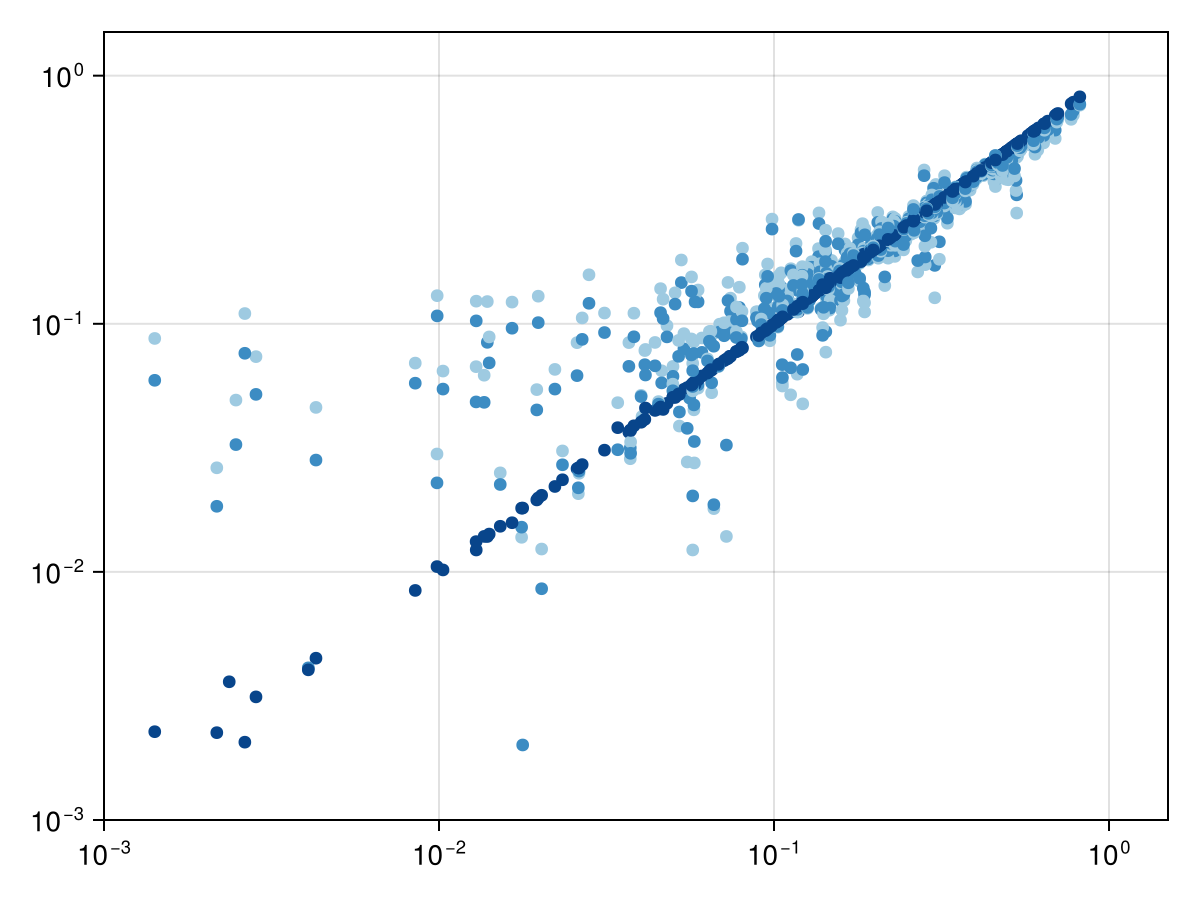

In [170]:
fig = Figure()
ax = Axis(fig[1,1];
    xscale=log10,
    yscale=log10,
)

for r in eachrow(m9_df)
    # if r.p != 1
        # continue
    # end
    scatter!(ax, r.so_hss ./ sum(r.so_hss), r.so_fs ./ sum(r.so_fs);
        color=p_color(r.p),
    )
end

mm = 1e-3
xlims!(ax, mm, 1.5)
ylims!(ax, mm, 1.5)

fig